In [5]:
# Phase#2: Data Summarization and Preprocessing
# 1. Data Analysis
# 1.1 Data Loading and Initial Inspection
#In this section, we load the dataset and perform an initial check on its structure and content.

In [8]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('Depression Student Dataset.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [9]:
# Statistical summary for numeric attributes
print("Statistical Summary (Five-Number Summary):")
df.describe()

Statistical Summary (Five-Number Summary):


,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


In [12]:
#"The table above shows the five-number summary (Min, Q1, Median, Q3, and Max) for all numeric attributes. This helps us understand the central tendency and the spread of our data."

In [13]:
# Check for missing values in each column
print("Missing Values Analysis:")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a summary table
missing_summary = pd.concat([missing_data, missing_percent], axis=1, keys=['Total Missing', 'Percentage (%)'])
missing_summary

Missing Values Analysis:


,Total Missing,Percentage (%)
Gender,0,0.0
Age,0,0.0
Academic Pressure,0,0.0
Study Satisfaction,0,0.0
Sleep Duration,0,0.0
Dietary Habits,0,0.0
Have you ever had suicidal thoughts ?,0,0.0
Study Hours,0,0.0
Financial Stress,0,0.0
Family History of Mental Illness,0,0.0


In [14]:
#A preliminary Missing Value Analysis was conducted to ensure data integrity. The analysis confirmed that our current dataset contains no missing values across all attributes. However, had any incomplete data been detected, our preprocessing protocol would have involved:
#Row Deletion: Removing records with a high percentage of missing features if they represented a small portion of the total sample.
#Imputation: Filling missing numerical values using the mean or median, and categorical values using the mode, to maintain the dataset size.
#Since the data is 100% complete, we proceeded directly to the next stages of analysis without any data loss or synthetic estimation.

In [15]:
# Check data types (Numeric vs Nominal)
print("Dataset Information and Data Types:")
df.info()

Dataset Information and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                            

In [16]:
#The output of the df.info() function provides a comprehensive summary of the dataset's structure. It consists of 502 entries and 11 columns. Notably, there are no missing values across all features, as indicated by the '502 non-null' count for every column. The dataset contains a mix of data types: numeric variables (such as Age, Study Hours, and Financial Stress recorded as int64 or float64) and categorical variables (such as Gender, Dietary Habits, and Depression recorded as object). This initial inspection confirms that the data is clean in terms of completeness, though further encoding may be required for the categorical 'object' types to prepare them for statistical modeling.

In [17]:
print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(502, 11)


## Class Label Distribution Analysis

In this section, we analyze the distribution of the class label (Depression) to determine whether the dataset is balanced or imbalanced.

In [18]:

import matplotlib.pyplot as plt
label_col = "Depression"

if label_col not in df.columns:
    print("Available columns:", df.columns.tolist())
    raise ValueError("Column 'Depression' not found. Please check the column name.")


In [19]:
class_counts = df[label_col].value_counts(dropna=False)
print("Class Distribution:")
print(class_counts)

Class Distribution:
Depression
Yes    252
No     250
Name: count, dtype: int64


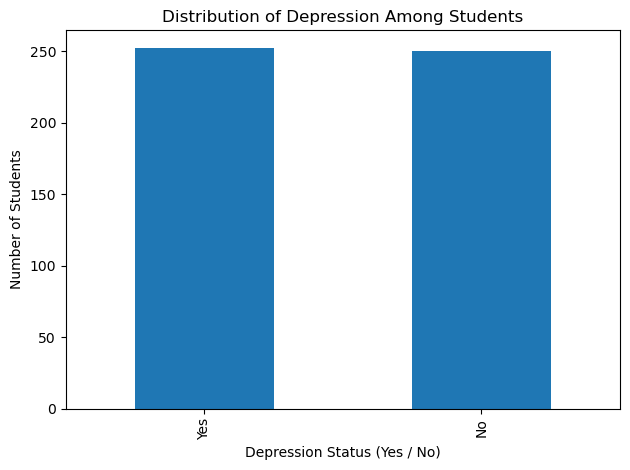

In [20]:
plt.figure()
class_counts.plot(kind='bar')
plt.title("Distribution of Depression Among Students")
plt.xlabel("Depression Status (Yes / No)")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

### Plot Description

The bar chart shows the distribution of depression status among students.

The x-axis represents the categories (Yes = Depressed, No = Not Depressed), and the y-axis represents the number of students in each category.

The dataset appears to be well balanced, as the number of depressed and non-depressed students is nearly equal. Therefore, no immediate imbalance treatment is required.

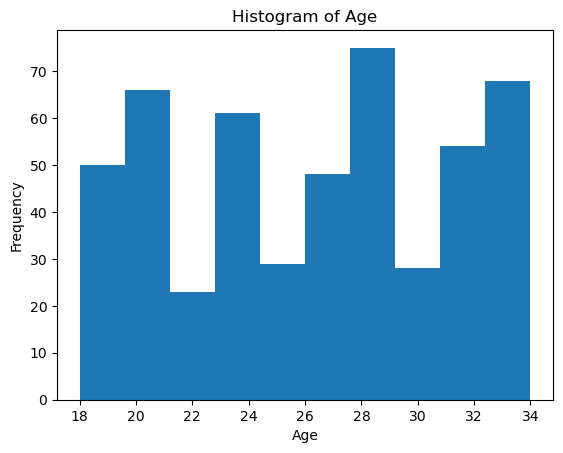

In [21]:
plt.hist(df["Age"], bins=10)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Histogram Analysis (Age)

The histogram shows that most students are between 22 and 30 years old.
The ages are fairly distributed with a slight concentration around the mid-20s.
The distribution appears relatively balanced without strong skewness.

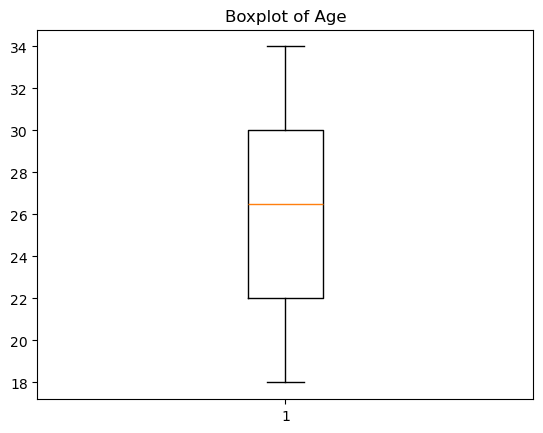

In [22]:
plt.boxplot(df["Age"])
plt.title("Boxplot of Age")
plt.show()

Boxplot Analysis (Age)

The boxplot shows that the median age is around 26 years.
The interquartile range indicates that most students fall between approximately 22 and 30 years.
No significant outliers are observed in the dataset.

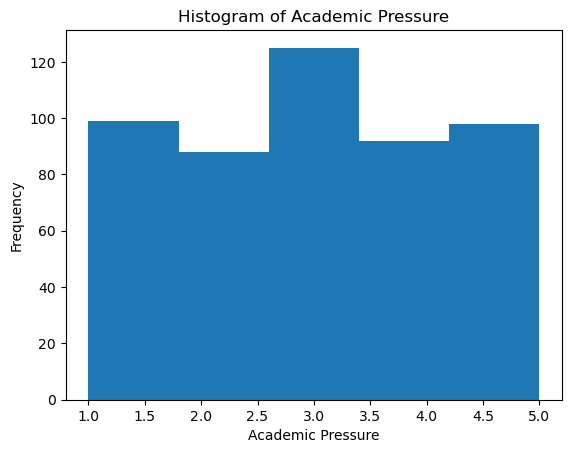

In [23]:
plt.figure()
plt.hist(df["Academic Pressure"], bins=5)
plt.title("Histogram of Academic Pressure")
plt.xlabel("Academic Pressure")
plt.ylabel("Frequency")
plt.show()

Histogram Analysis (Academic Pressure)

The histogram shows the distribution of academic pressure on a 1–5 Likert scale (ordinal).
Most students report moderate pressure levels, with no strong skewness observed.

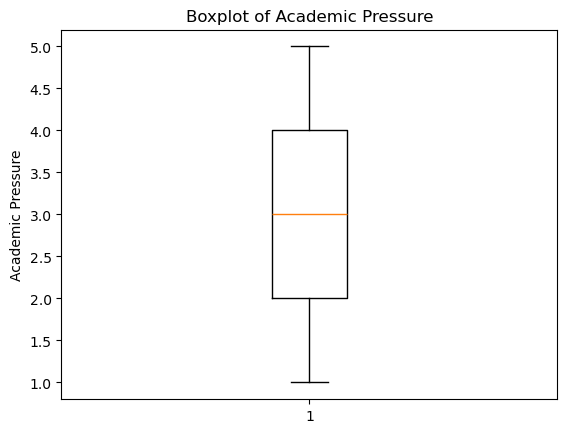

In [24]:
plt.figure()
plt.boxplot(df["Academic Pressure"])
plt.title("Boxplot of Academic Pressure")
plt.ylabel("Academic Pressure")
plt.show()

Boxplot Analysis (Academic Pressure)

The boxplot shows that the median is around the middle of the scale.
There are no significant extreme outliers, and the spread appears reasonable.


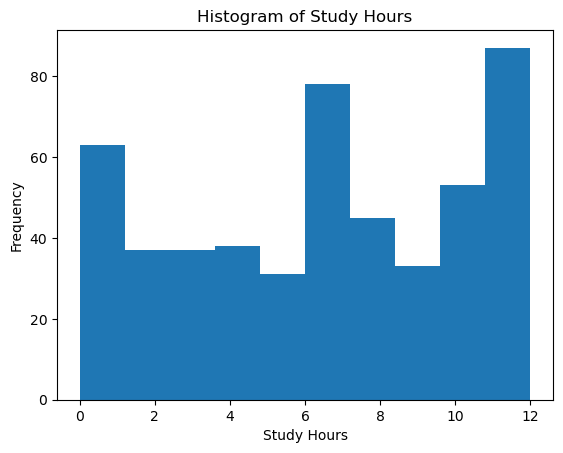

In [25]:
plt.figure()
plt.hist(df["Study Hours"], bins=10)
plt.title("Histogram of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()

Histogram Analysis (Study Hours)

The histogram shows the most common study-hour ranges among students.  
It helps determine whether students typically study fewer hours or if the distribution shifts toward higher study hours.

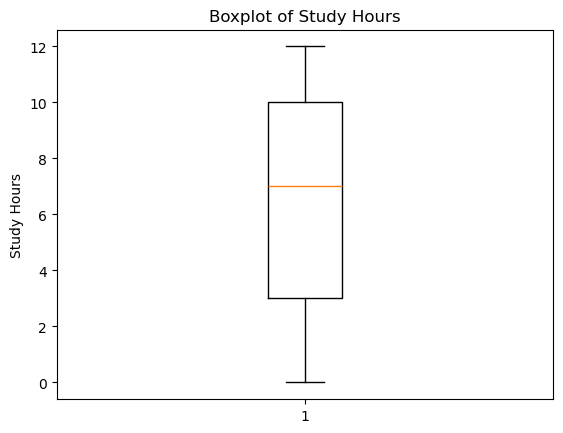

In [26]:
plt.figure()
plt.boxplot(df["Study Hours"])
plt.title("Boxplot of Study Hours")
plt.ylabel("Study Hours")
plt.show()

Boxplot Analysis (Study Hours)
The boxplot displays the median study hours and the variability among students.  
Outliers (if present) represent students who study significantly more or less than the majority.